In [37]:
import os
import copy
import skillsnetwork

import numpy as np
from numpy.core.fromnumeric import reshape

import tensorflow as tf

import keras
from keras import layers, Input, Sequential
from keras.layers import Dense, Flatten, Reshape, Conv2DTranspose, Conv2D
from keras.models import Model

def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

In [38]:
def plot_images(top, bottom, start = 0, stop = 5, reshape_x = (28,28), reshape_xhat= (28,28)):
    n_samples = stop - start

    for i, img_index in enumerate(range(start, stop)):
        ax = plt.subplot(2, n_samples, i+1)
        plt.imshow(top[img_index].reshape(reshape_x[0], reshape_x[1]), cmap='gray')

        if i == n_samples//2:
            plt.title("original images")

        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

        ax = plt.subplot(2,n_samples, i+1+n_samples)
        plt.imshow(bottom[img_index].reshape(reshape_xhat[0], reshape_xhat[1]), cmap='gray')

        if i == n_samples//2:
            plt.title("encoded images")

        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

In [39]:
def graph_history(history, title="Log Loss and Accuracy over iterations"):

    fig = plt.figure(figsize=(16,8))
    fig.suptitle(title)
    N_plots = len(history.history.keys())
    color_list=['b', 'r', 'g', 'c', 'm', 'y', 'k', 'w','bx','rx']
    for i, (key, items) in enumerate(history.history.items()):
        ax = fig.add_subplot(1, N_plots, i+1)
        ax.plot(items, c=color_list[i])
        ax.grid(True)
        ax.set(xlabel='iterations', title=key)

In [40]:
def add_noise(X_train, X_test, noise_factor = 0.3):
    X_train_noisy = X_train + noise_factor * tf.random.normal(shape=X_train.shape)
    X_test_noisy = X_test + noise_factor * tf.random.normal(shape=X_test.shape)

    X_train_noisy = tf.clip_by_value(X_train_noisy, clip_value_min=0., clip_value_max=1.).numpy()
    X_test_noisy = tf.clip_by_value(X_test_noisy, clip_value_min=0., clip_value_max=1.).numpy()

    return X_train_noisy, X_test_noisy

In [41]:
def plot_code(h, y, numbers=list(range(0, 10)), scale=[1,1,1]):
    h = h.numpy()
    color_list=['b', 'g', 'r', 'c', 'm', 'y', 'k', 'pink','darkorange','lime']
    logic_array = np.zeros(len(y), dtype=bool)

    fig=plt.figure(figsize=(6,6))
    ax = fig.add_subplot(111, projection='3d')

    for num, color in zip(numbers, color_list):
        logic_array = (y==num)
        plt.scatter(scale[0]*h[logic_array, 0], scale[1]*h[logic_array, 1], scale[2]*h[logic_array, 2], c=color_list, label = num)
    plt.title("3D output of encoder, colored by digits")
    plt.legend(loc=[1.1, 0.3])
    plt.show()

In [42]:
def avg(shape, dtype=None):
    grad = np.array([
        [1, 1, 1],
        [1, 1, 1],
        [1, 1, 1]
        ]).reshape((3, 3, 1, 1))/9
    
    assert grad.shape == shape
    return keras.backend.variable(grad, dtype='float32')

a_conv = layers.Conv2D(filters=1,
                       kernel_size=3,
                       kernel_initializer=avg,
                       strides=1,
                       padding='same')

In [43]:
def display_auto(Xiter,n=1,B=1):

    """
    This function displays the ouput of an autoencder 
    Returns:  void images 
    Args: 
    Xiter:image_dataset_from_directory object converted to iterator 
    n:sample within batch 
    B: batch number 
    """

    for b in range(B):    
        x = next(Xiter)
    
        plt.imshow(x[1].numpy()[n,:,:,0],cmap="gray")
        plt.title("input")
        plt.show()
        plt.imshow(x[0].numpy()[n,:,:,0],cmap="gray")
        plt.title("output")
        plt.show()

In [63]:
from keras.datasets import mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print(X_train.shape)
print(X_test.shape)

X_train = X_train.astype('float32')/255
X_test = X_test.astype(np.float32)/255
X_train = X_train.reshape((len(X_train), np.prod(X_train.shape[1:])))
X_test = X_test.reshape((len(X_test), np.prod(X_test.shape[1:])))

print(X_train.shape)
print(X_test.shape)

(60000, 28, 28)
(10000, 28, 28)
(60000, 784)
(10000, 784)


In [64]:
input_img = Input(shape = (784, ))

In [65]:
encoding_dim = 36
encoder = Dense(encoding_dim, activation='relu')(input_img)

In [66]:
decoder = Dense(784, activation='sigmoid')(encoder)

In [67]:
autoencoder = Model(input_img, decoder)

In [68]:
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

In [69]:
history = autoencoder.fit(X_train, X_train, 
                          epochs=25,
                          batch_size=256,
                          shuffle=True,
                          validation_data=(X_test, X_test))

Epoch 1/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.2701 - val_loss: 0.1835
Epoch 2/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1659 - val_loss: 0.1486
Epoch 3/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1394 - val_loss: 0.1291
Epoch 4/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1239 - val_loss: 0.1167
Epoch 5/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1137 - val_loss: 0.1083
Epoch 6/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1065 - val_loss: 0.1024
Epoch 7/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1011 - val_loss: 0.0978
Epoch 8/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0973 - val_loss: 0.0946
Epoch 9/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0946 - val_loss: 0.0924
Epoch 10/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0929 - val_loss: 0.0910
Epoch 11/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0917 - val_loss: 0.0900
Epoch 12/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

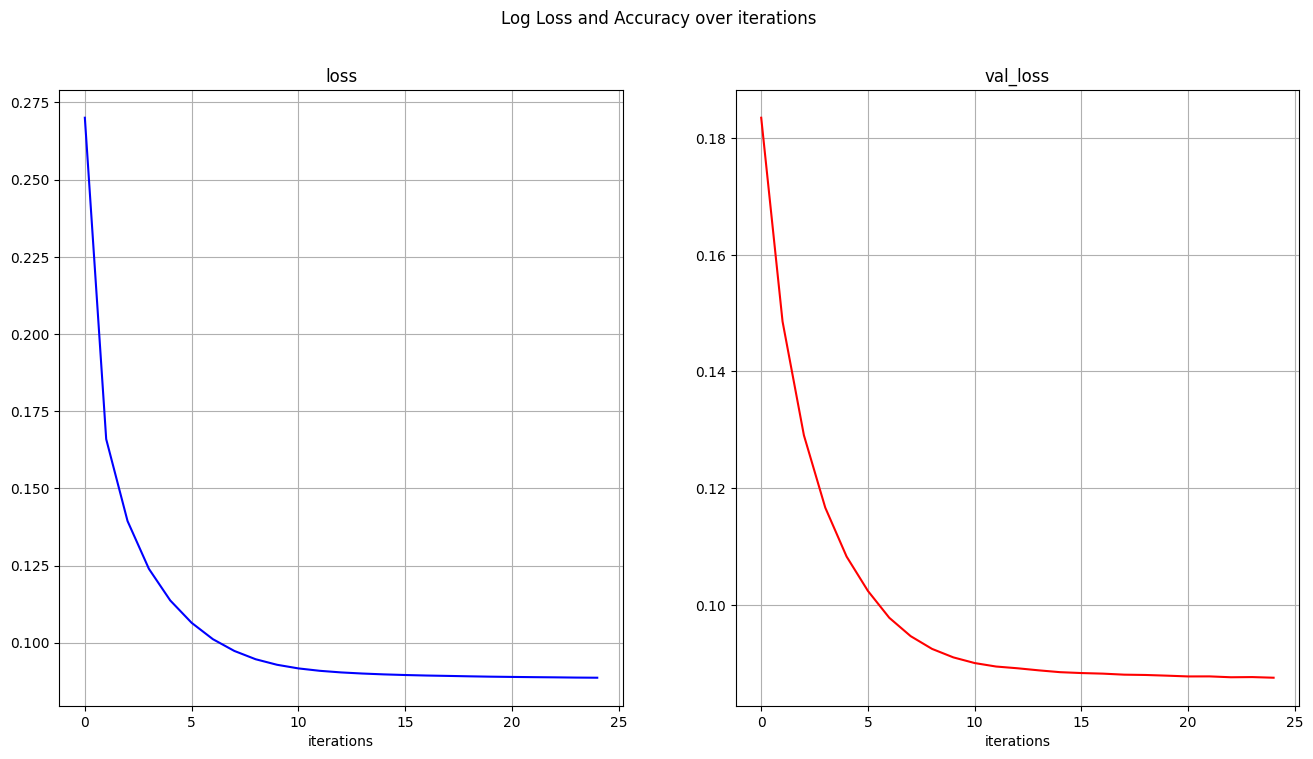

In [70]:
graph_history(history)

In [71]:
xhat = autoencoder.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 969us/step


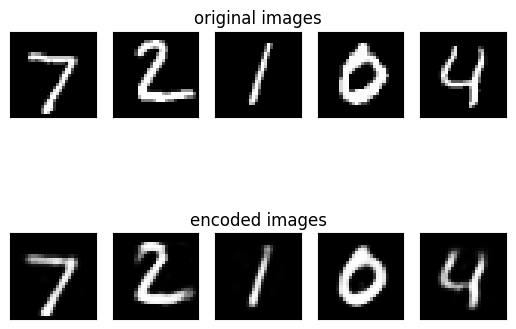

In [72]:
plot_images(X_test, xhat, start=0, stop=5)

In [73]:
class Autoencoder(tf.keras.Model):
    def __init__(self, latent_dim):
        super(Autoencoder, self).__init__()
        self.latent_dim = latent_dim
        self.encoder = Dense(latent_dim, activation='relu')
        self.decoder = Dense(784, activation='sigmoid')

    def call(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

In [74]:
encoding_dim = 36
autoencoder = Autoencoder(encoding_dim)

Epoch 1/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.2698 - val_loss: 0.1852
Epoch 2/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1674 - val_loss: 0.1505
Epoch 3/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1412 - val_loss: 0.1303
Epoch 4/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1248 - val_loss: 0.1173
Epoch 5/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1139 - val_loss: 0.1083
Epoch 6/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1061 - val_loss: 0.1018
Epoch 7/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1007 - val_loss: 0.0973
Epoch 8/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0969 - val_loss: 0.0942
Epoch 9/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0943 - val_loss: 0.0922
Epoch 10/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0926 - val_loss: 0.0910
Epoch 11/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0916 - val_loss: 0.0900
Epoch 12/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

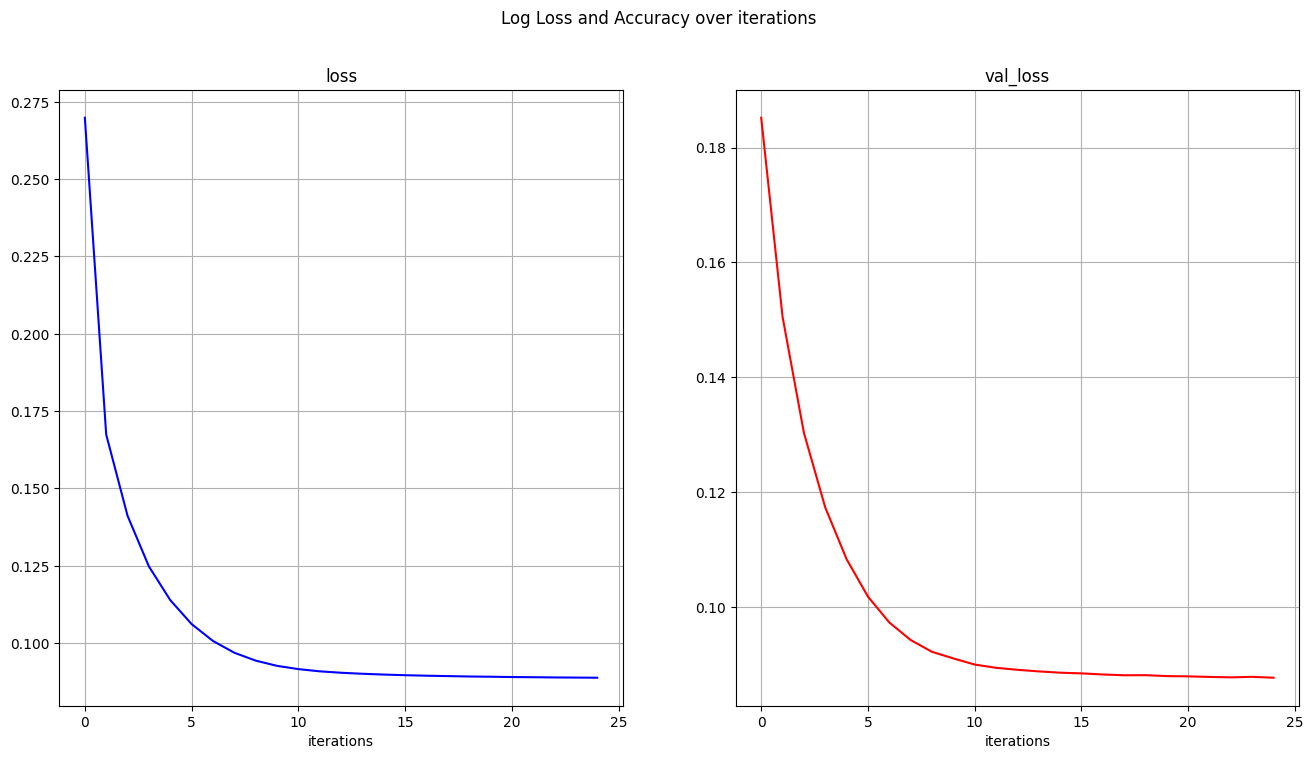

In [75]:
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
history = autoencoder.fit(X_train, X_train, epochs=25, batch_size=256, shuffle=True, validation_data=(X_test, X_test))
graph_history(history=history)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 901us/step


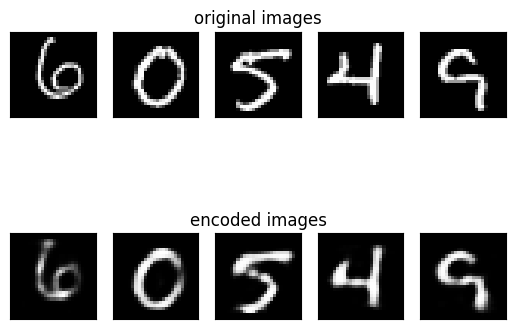

In [77]:
xhat = autoencoder.predict(X_test)
plot_images(X_test,xhat, start=100, stop=105)

In [78]:
h = autoencoder.encoder(X_test)
h.shape

TensorShape([10000, 36])

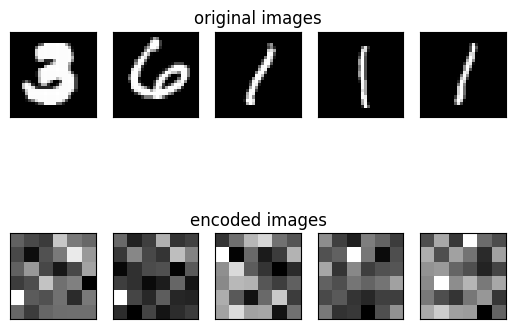

In [79]:
plot_images(X_test, h.numpy(), start=200, stop=205, reshape_x=(28, 28), reshape_xhat=(6,6))